# Downloading the Data

In [1]:
from datasets import load_dataset
import os

# Define the local directory to save the datasets for cluster upload
SAVE_DIR = "odqa_data"
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
print("Downloading SQUAD-TR dataset...")

# Added trust_remote_code=True to allow the custom dataset script to run
squad_tr_open_qa = load_dataset("boun-tabi/squad_tr", "openqa")

# Display the dataset structure (train and validation splits)
print("SQUAD-TR Structure:")
print(squad_tr_open_qa)

# Save to disk
squad_tr_path = os.path.join(SAVE_DIR, "squad_tr")
squad_tr_open_qa.save_to_disk(squad_tr_path)
print(f"Saved SQUAD-TR to {squad_tr_path}")

/cta/users/buse/miniconda3/envs/odqa_env/lib/python3.10/site-packages/datasets/load.py:1429: FutureWarning: The repository for boun-tabi/squad_tr contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/boun-tabi/squad_tr
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


SQUAD-TR Structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})


Saving the dataset (0/1 shards):   0%|          | 0/130319 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11873 [00:00<?, ? examples/s]

Saved SQUAD-TR to odqa_data/squad_tr


In [3]:
print("Downloading Turkish Wikipedia dump (20230901.tr)...")

# Load the specific 2023 subset from graelo/wikipedia
wiki_tr = load_dataset("graelo/wikipedia", "20230901.tr", split="train")

# Display the dataset structure (should show ~531k rows)
print("Wikipedia TR Structure:")
print(wiki_tr)

# Save to disk
wiki_tr_path = os.path.join(SAVE_DIR, "wiki_20230901_tr")
wiki_tr.save_to_disk(wiki_tr_path)
print(f"Saved Wikipedia TR to {wiki_tr_path}")

/cta/users/buse/miniconda3/envs/odqa_env/lib/python3.10/site-packages/datasets/load.py:1429: FutureWarning: The repository for graelo/wikipedia contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/graelo/wikipedia
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Wikipedia TR Structure:
Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 530830
})


Saving the dataset (0/2 shards):   0%|          | 0/530830 [00:00<?, ? examples/s]

Saved Wikipedia TR to odqa_data/wiki_20230901_tr


In [4]:
# Squad train and validation set word counts distributions
# Calculate mean, 25 percentile, and 75 percentile word counts for train and validation sets
def calculate_word_counts(dataset):
    word_counts = []
    for item in dataset:
        if "question" in item and "context" in item:
            total_words = len(item["question"].split()) + len(item["context"].split())
            word_counts.append(total_words)
    return word_counts

squad_tr_word_counts = calculate_word_counts(squad_tr_open_qa["train"])
squad_tr_mean_words = sum(squad_tr_word_counts) / len(squad_tr_word_counts) if squad_tr_word_counts else 0
print(f"Mean word count for SQUAD-TR train set: {squad_tr_mean_words:.2f}")
squad_tr_val_word_counts = calculate_word_counts(squad_tr_open_qa["validation"])
squad_tr_val_mean_words = sum(squad_tr_val_word_counts) / len(squad_tr_val_word_counts) if squad_tr_val_word_counts else 0
print(f"Mean word count for SQUAD-TR validation set: {squad_tr_val_mean_words:.2f}")
# Mean count for all Squad-TR, weighted by the number of samples in train and validation
total_samples = len(squad_tr_open_qa["train"]) + len(squad_tr_open_qa["validation"])
overall_mean_words = (squad_tr_mean_words * len(squad_tr_open_qa["train"]) + squad_tr_val_mean_words * len(squad_tr_open_qa["validation"])) / total_samples
print(f"Overall mean word count for SQUAD-TR: {overall_mean_words:.2f}")


Mean word count for SQUAD-TR train set: 101.00
Mean word count for SQUAD-TR validation set: 107.13
Overall mean word count for SQUAD-TR: 101.51


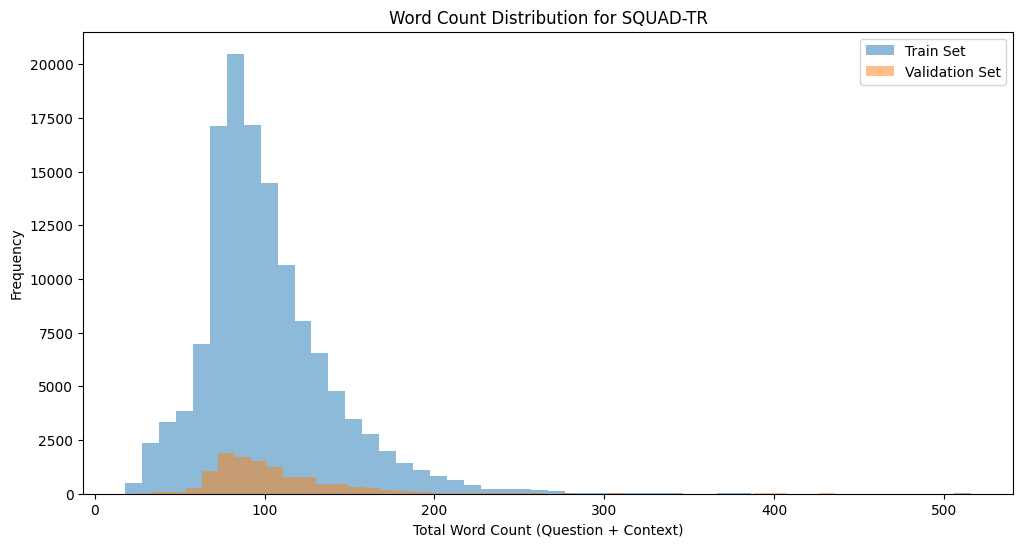

In [5]:
# Plotting the word count distribution for SQUAD-TR train and validation sets
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(squad_tr_word_counts, bins=50, alpha=0.5, label="Train Set")
plt.hist(squad_tr_val_word_counts, bins=50, alpha=0.5, label="Validation Set")
plt.title("Word Count Distribution for SQUAD-TR")
plt.xlabel("Total Word Count (Question + Context)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Preprocessing the Dataset

In [6]:
import string
import os

def chunk_passages(batch, indices, source_name, drop_long_texts=False):
    titles = batch['title']
    texts = batch['text']
    source_ids = batch['id']
    
    chunked_titles = []
    chunked_texts = []
    chunked_ids = []
    
    chunk_size = 200
    
    for idx, (title, text, source_id) in enumerate(zip(titles, texts, source_ids)):
        source_index = indices[idx]

        # Skip if there is no text to chunk
        if not text:
            continue
            
        # Enhanced Whitespace Tokenizer (applied only to the text)
        # Pad punctuation with spaces so they are treated as distinct tokens
        processed_text = text
        for punc in string.punctuation:
            processed_text = processed_text.replace(punc, f" {punc} ")
            
        # Split purely by whitespace
        tokens = processed_text.split()

        if drop_long_texts and len(tokens) > chunk_size:
            continue
        
        # Split into equal chunks of 200 words
        for chunk_idx in range(0, len(tokens), chunk_size):
            chunk = tokens[chunk_idx:chunk_idx + chunk_size]
            
            # Keep the title separate for FiD
            chunked_titles.append(title)
            
            # Join the tokens back into a string chunk
            chunk_str = " ".join(chunk)
            
            # Clean up the punctuation spacing for readability 
            chunk_str = chunk_str.replace(" .", ".").replace(" ,", ",").replace(" ' ", "'")
            
            chunked_texts.append(chunk_str)
            chunked_ids.append(f"{source_name}-{source_id}-{source_index}-{chunk_idx // chunk_size}")
            
    return {"title": chunked_titles, "text": chunked_texts, "id": chunked_ids}


def chunk_wikipedia_passages(batch, indices):
    return chunk_passages(batch, indices, "wiki")

print("Chunking Turkish Wikipedia into 200-word segments...")

# Apply the mapping function to the dataset
wiki_tr_chunked = wiki_tr.map(
    chunk_wikipedia_passages, 
    batched=True, 
    with_indices=True,
    remove_columns=wiki_tr.column_names, 
    desc="Chunking Wikipedia passages"
)

print("New Chunked Wikipedia TR Structure:")
print(wiki_tr_chunked)

# Save the preprocessed chunks back to disk
chunked_path = os.path.join(SAVE_DIR, "wiki_20230901_tr_chunked_200")
wiki_tr_chunked.save_to_disk(chunked_path)
print(f"Saved chunked Wikipedia TR to {chunked_path}")

Chunking Turkish Wikipedia into 200-word segments...
New Chunked Wikipedia TR Structure:
Dataset({
    features: ['id', 'title', 'text'],
    num_rows: 1075986
})


Saving the dataset (0/2 shards):   0%|          | 0/1075986 [00:00<?, ? examples/s]

Saved chunked Wikipedia TR to odqa_data/wiki_20230901_tr_chunked_200


In [7]:
import pandas as pd
from datasets import Dataset, concatenate_datasets

print("Extracting unique context passages from SQUAD-TR...")

# Convert the train split to a pandas DataFrame for easy deduplication
squad_train_df = squad_tr_open_qa['train'].to_pandas()
squad_val_df = squad_tr_open_qa['validation'].to_pandas()

merged_squad_df = pd.concat([squad_train_df, squad_val_df], ignore_index=True)

# Filter down to just titles and contexts, drop duplicates, and rename 'context' to 'text' 
# so it matches the input format expected by our chunk_wikipedia_passages function
unique_squad_df = merged_squad_df[['id', 'title', 'context']].drop_duplicates().rename(columns={'context': 'text'})
#drop duplicates based on the 'text' column to ensure we only have unique passages, even if they have different titles or ids
unique_squad_df = unique_squad_df.drop_duplicates(subset=['text'])

# Convert back to a Hugging Face Dataset
squad_unique_ds = Dataset.from_pandas(unique_squad_df, preserve_index=False)
print(f"Extracted {len(squad_unique_ds)} unique passages from SQUAD-TR.")

print("Chunking the SQUAD-TR passages into 200-word segments...")
# Apply the exact same chunking function we used on the Wikipedia dump
squad_chunked = squad_unique_ds.map(
    lambda batch, indices: chunk_passages(batch, indices, "squad", drop_long_texts=True),
    batched=True, 
    with_indices=True,
    remove_columns=squad_unique_ds.column_names,
    desc="Chunking SQUAD-TR passages"
)

print("Concatenating Wikipedia and SQUAD-TR chunks...")
# Combine both chunked datasets into the final knowledge source
final_knowledge_source = concatenate_datasets([wiki_tr_chunked, squad_chunked])

print("\nFinal Knowledge Source Structure:")
print(final_knowledge_source)

# Save the final, combined, and chunked dataset to disk for the cluster
final_path = os.path.join(SAVE_DIR, "final_knowledge_source_chunked_200")
final_knowledge_source.save_to_disk(final_path)
print(f"\nSaved final combined knowledge source to {final_path}")

Extracting unique context passages from SQUAD-TR...
Extracted 20232 unique passages from SQUAD-TR.
Chunking the SQUAD-TR passages into 200-word segments...


Chunking SQUAD-TR passages:   0%|          | 0/20232 [00:00<?, ? examples/s]

Concatenating Wikipedia and SQUAD-TR chunks...

Final Knowledge Source Structure:
Dataset({
    features: ['id', 'title', 'text'],
    num_rows: 1095020
})


Saving the dataset (0/3 shards):   0%|          | 0/1095020 [00:00<?, ? examples/s]


Saved final combined knowledge source to odqa_data/final_knowledge_source_chunked_200


In [9]:
# Prepare Squad TR dataset: Create a finetuning_eval set 

import pandas as pd
from collections import defaultdict
from datasets import load_dataset

squad_tr_open_qa = load_dataset("boun-tabi/squad_tr", "openqa")

# A dictionary containing the ids of questions with the same title in squad dataset
# Remove questions with word count > 200
question_ids = defaultdict(list)
for i in range(len(squad_tr_open_qa['train'])):
    if (squad_tr_open_qa['train'][i]['answers']['text'] != [] 
        and len(squad_tr_open_qa['train'][i]['context'].split()) <= 200):
        title = squad_tr_open_qa['train'][i]['title']
        question_id = squad_tr_open_qa['train'][i]['id']
        question_ids[(title)].append(question_id)

print(len(question_ids.keys()))
# Put in a table the number of ids for each title
df = pd.DataFrame([(title, len(ids)) for title, ids in question_ids.items()], columns=['Title', 'Number of IDs'])
df.sort_values(by='Number of IDs', ascending=False)

# Sample 5% of titles and get the corresponding question ids to create a validation set

validation_ids = [ids for title, ids in question_ids.items() if title in df.sample(frac=0.05, random_state=42)['Title'].tolist()] 
validation_ids = [item for sublist in validation_ids for item in sublist]
print(f"Number of validation ids: {len(validation_ids)}")
train_ids = [ids for title, ids in question_ids.items() if title not in df.sample(frac=0.05, random_state=42)['Title'].tolist()] 
train_ids = [item for sublist in train_ids for item in sublist]
print(f"Number of training ids: {len(train_ids)}")

# Save the new train and validation splits to disk
train_df = squad_tr_open_qa['train'].filter(lambda x: x['id'] in train_ids)
validation_df = squad_tr_open_qa['train'].filter(lambda x: x['id'] in validation_ids)

train_df.save_to_disk(os.path.join(SAVE_DIR, "squad_tr_finetuning_train"))
validation_df.save_to_disk(os.path.join(SAVE_DIR, "squad_tr_finetuning_validation"))
print("Saved new SQUAD-TR finetuning train and validation splits to disk.")

/cta/users/buse/miniconda3/envs/odqa_env/lib/python3.10/site-packages/datasets/load.py:1429: FutureWarning: The repository for boun-tabi/squad_tr contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/boun-tabi/squad_tr
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


440
Number of validation ids: 5036
Number of training ids: 80271


Filter:   0%|          | 0/130319 [00:00<?, ? examples/s]

Filter:   0%|          | 0/130319 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/80271 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5036 [00:00<?, ? examples/s]

Saved new SQUAD-TR finetuning train and validation splits to disk.


In [10]:
# Filter test set to only include questions with word count <= 200
test_df = squad_tr_open_qa['validation'].filter(lambda x: len(x['context'].split()) <= 200)
test_df.save_to_disk(os.path.join(SAVE_DIR, "squad_tr_finetuning_test"))
print("Saved new SQUAD-TR finetuning test split to disk.")

Filter:   0%|          | 0/11873 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11505 [00:00<?, ? examples/s]

Saved new SQUAD-TR finetuning test split to disk.
